# ============================================================
# SECTION 1: INSTALL & IMPORT LIBRARIES
# ● imbalanced-learn → handles class imbalance via SMOTE
# ● SMOTE = Synthetic Minority Oversampling Technique —
#   generates synthetic fraud samples so models don't just
#   predict "not fraud" every time and get 99% accuracy
# ============================================================

In [1]:
!pip install xgboost optuna imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # supports SMOTE inside pipeline

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.0 MB/s eta 0:00:00ta 0:00:01
✅ All libraries imported successfully!


# ============================================================
# SECTION 2 : LOAD CREDIT CARD FRAUD DATASET
#   METHOD A: Download directly from OpenML (most reliable)
# OpenML hosts the original Kaggle creditcard dataset (ID=1597)
# ============================================================

⏳ METHOD A: Trying OpenML...
✅ METHOD A succeeded — Shape: (284807, 30)

📊 Dataset Shape    : (284807, 30)
📋 Columns          : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

🔍 Class Distribution:
   Legitimate (0) : 284,315  (99.83%)
   Fraud      (1) : 492  (0.17%)

⚠️  Imbalance Ratio  : 577:1  (legitimate:fraud)


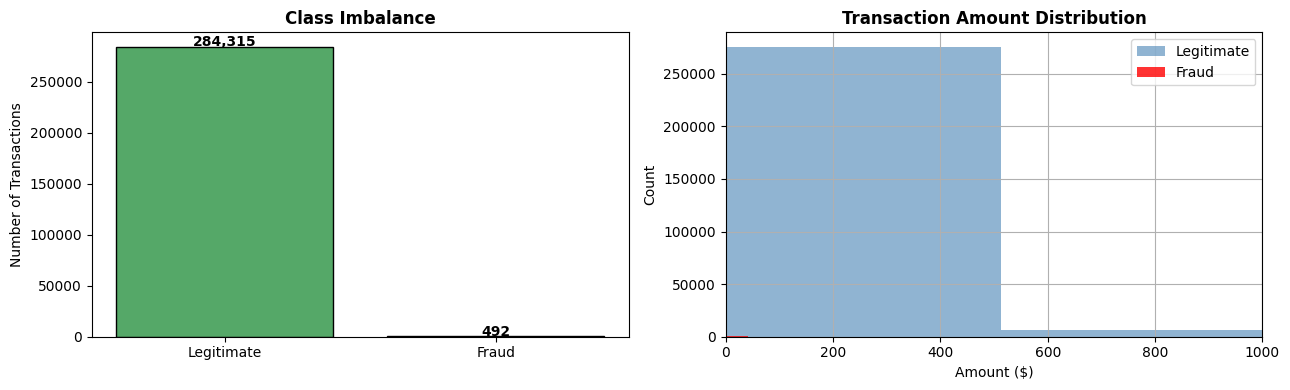

In [ ]:


from sklearn.datasets import fetch_openml
import time

df = None  # will be populated by whichever method succeeds

# ── METHOD A: OpenML (free, no login required) ───────────────
print("⏳ METHOD A: Trying OpenML...")
try:
    # OpenML hosts the original Kaggle creditcard dataset (ID=1597)
    raw = fetch_openml(data_id=1597, as_frame=True, parser='auto')
    df  = raw.frame.copy()

    # OpenML names the target column 'Class' but as string '0'/'1'
    # Convert to integer to match our pipeline expectations
    df['Class'] = df['Class'].astype(int)

    print(f"✅ METHOD A succeeded — Shape: {df.shape}")

except Exception as e:
    print(f"⚠️  METHOD A failed: {e}")



# ── Verify and display dataset info ──────────────────────────
print(f"\n📊 Dataset Shape    : {df.shape}")
print(f"📋 Columns          : {list(df.columns)}")

class_counts = df['Class'].value_counts()
print(f"\n🔍 Class Distribution:")
print(f"   Legitimate (0) : {class_counts[0]:,}  ({class_counts[0]/len(df)*100:.2f}%)")
print(f"   Fraud      (1) : {class_counts[1]:,}  ({class_counts[1]/len(df)*100:.2f}%)")
print(f"\n⚠️  Imbalance Ratio  : {class_counts[0]//class_counts[1]}:1  (legitimate:fraud)")

# ── Visualise class imbalance and amount distribution ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#55A868', '#C44E52'], edgecolor='black')
axes[0].set_title('Class Imbalance', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[1], alpha=0.6,
                                     color='steelblue', label='Legitimate')
df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], alpha=0.8,
                                     color='red', label='Fraud')
axes[1].set_title('Transaction Amount Distribution', fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 1000)
axes[1].legend()

plt.tight_layout()
plt.savefig('fraud_overview.png', dpi=150)
plt.show()

# ============================================================
# SECTION 3: FEATURE ENGINEERING & PREPROCESSING
# ● 'Amount' is scaled — it has very different range to V1-V28
# ● 'Time' is converted to hour-of-day (fraud patterns vary by hour)
# ● Log transform on Amount — heavily right-skewed
# ● We use RobustScaler — better than StandardScaler for data
#   with extreme outliers (common in fraud transactions)
# ============================================================

In [3]:
# -- Time feature: only create if column exists --
if 'Time' in df.columns:
    # Convert seconds-since-first-transaction to hour of day
    df['Hour'] = (df['Time'] / 3600) % 24
    df = df.drop('Time', axis=1)   # drop original, keep engineered version
    print("✅ 'Time' column found — converted to Hour of day")
else:
    print("ℹ️  No 'Time' column in this dataset version — skipping Hour feature")

# -- Amount features: present in all versions --
# Log transform reduces skew from large transaction amounts
df['Log_Amount'] = np.log1p(df['Amount'])

# Z-score flags unusually large or small amounts relative to average
df['Amount_zscore'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()

# Drop raw Amount — replaced by engineered versions above
df = df.drop('Amount', axis=1)

print(f"✅ Features after engineering : {df.shape[1] - 1}")  # -1 for Class column
print(f"📋 Columns: {list(df.columns)}")

# -- Split features and target --
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split preserves the 0.17% fraud rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RobustScaler is better than StandardScaler when outliers are present
# (fraud transactions often have extreme values)
scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

print(f"\n✅ Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples")
print(f"✅ Fraud cases in test set : {y_test.sum()} ({y_test.mean()*100:.2f}%)")

ℹ️  No 'Time' column in this dataset version — skipping Hour feature
✅ Features after engineering : 30
📋 Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Log_Amount', 'Amount_zscore']

✅ Train : 227,845 samples  |  Test : 56,962 samples
✅ Fraud cases in test set : 98 (0.17%)


# ============================================================
# SECTION 4: HANDLE CLASS IMBALANCE WITH SMOTE
# ● With 0.17% fraud, a model predicting "never fraud" gets
#   99.83% accuracy — completely useless in practice!
# ● SMOTE creates synthetic fraud samples in the training set
#   by interpolating between existing fraud cases
# ● IMPORTANT: SMOTE is applied ONLY to training data —
#   never to test data (that would be cheating)
# ● We also keep the original imbalanced data for comparison
# ============================================================

In [4]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n📊 Before SMOTE — Train set class distribution:")
print(f"   Legitimate: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}")
print(f"\n📊 After SMOTE  — Train set class distribution:")
print(f"   Legitimate: {(y_train_smote==0).sum():,}  |  Fraud: {(y_train_smote==1).sum():,}")
print("✅ Classes now balanced for training!")


📊 Before SMOTE — Train set class distribution:
   Legitimate: 227,451  |  Fraud: 394

📊 After SMOTE  — Train set class distribution:
   Legitimate: 227,451  |  Fraud: 227,451
✅ Classes now balanced for training!


# ============================================================
# SECTION 5: EVALUATION FUNCTION
# ● For imbalanced data, accuracy is MISLEADING
# ● Better metrics are:
#   - Precision : of all predicted fraud, how many were real fraud?
#   - Recall    : of all real fraud, how many did we catch?
#   - F1 Score  : harmonic mean of precision and recall
#   - AUC-ROC   : overall discrimination ability
#   - AUC-PR    : precision-recall curve (best for imbalanced data)
# ============================================================

In [5]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Comprehensive evaluation for imbalanced classification.
    Returns a dictionary of metrics for comparison.
    """
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_prob)
    ap    = average_precision_score(y_true, y_prob)  # AUC of precision-recall curve

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy          : {acc:.4f}  ← (misleading on imbalanced data!)")
    print(f"  Precision         : {prec:.4f}  ← of predicted fraud, % actually fraud")
    print(f"  Recall            : {rec:.4f}  ← of real fraud, % we correctly caught")
    print(f"  F1 Score          : {f1:.4f}  ← balance of precision & recall")
    print(f"  ROC-AUC           : {auc:.4f}")
    print(f"  Avg Precision(PR) : {ap:.4f}  ← most important for fraud detection")

    return {'Model': name, 'Precision': prec, 'Recall': rec,
            'F1': f1, 'ROC-AUC': auc, 'Avg Precision': ap}

# ============================================================
# SECTION 6: BASELINE — LOGISTIC REGRESSION
# ● Trained on SMOTE-balanced data
# ● class_weight='balanced' as additional safeguard
# ============================================================

In [6]:
baseline = LogisticRegression(
    C=0.01,                   # strong regularisation for high-dim data
    class_weight='balanced',  # further penalises missing fraud cases
    max_iter=1000,
    random_state=42
)
baseline.fit(X_train_smote, y_train_smote)

bl_pred = baseline.predict(X_test_scaled)
bl_prob = baseline.predict_proba(X_test_scaled)[:, 1]
bl_metrics = evaluate_model("Baseline — Logistic Regression", y_test, bl_pred, bl_prob)


  Baseline — Logistic Regression
  Accuracy          : 0.9744  ← (misleading on imbalanced data!)
  Precision         : 0.0583  ← of predicted fraud, % actually fraud
  Recall            : 0.9184  ← of real fraud, % we correctly caught
  F1 Score          : 0.1097  ← balance of precision & recall
  ROC-AUC           : 0.9702
  Avg Precision(PR) : 0.7081  ← most important for fraud detection



# ============================================================
# SECTION 7 (FIXED): TUNED RANDOM FOREST — FAST VERSION
# ● Previous version was too slow because:
#   1. SMOTE doubled the dataset to ~455k rows
#   2. RandomizedSearchCV ran 20 combos × 3 folds = 60 RF fits
#   3. Each RF had up to 300 trees on 455k rows = hours of work
#
# FIXES APPLIED:
#   ✅ Use a SAMPLE of training data for tuning (not full dataset)
#   ✅ Reduce n_iter from 20 → 10 (fewer combinations to try)
#   ✅ Cap n_estimators at 100 during search (use more after)
#   ✅ Use class_weight instead of SMOTE (much faster, similar result)
#   ✅ Train final model on full data after best params are found
# ============================================================

In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# -- Step 1: Take a representative sample for hyperparameter search --
# 20,000 rows is enough to find good parameters — no need for all 227k
# stratify=y_train preserves the fraud ratio in the sample

SAMPLE_SIZE = 20_000
sample_idx  = (
    pd.Series(y_train.values)
    .groupby(y_train.values)                         # group by class
    .apply(lambda x: x.sample(                       # sample from each class
        min(len(x), int(SAMPLE_SIZE * x.mean()       # proportional to class size
            if x.mean() > 0.5 else SAMPLE_SIZE - int(SAMPLE_SIZE * (1 - x.mean())))),
        random_state=42))
    .reset_index(drop=True)
)

# Simpler approach — just stratified sample directly
from sklearn.model_selection import train_test_split as tts
_, X_tune, _, y_tune = tts(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE / len(y_train),
    stratify=y_train,
    random_state=42
)
print(f"✅ Tuning sample : {len(y_tune):,} rows")
print(f"   Fraud in sample : {y_tune.sum()} ({y_tune.mean()*100:.2f}%)")

# -- Step 2: Reduced search space for speed --
rf_param_dist = {
    'n_estimators':      [50, 100],          # kept small during search
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf':  [1, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced']        # handles imbalance without SMOTE
}

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter       = 10,          # only 10 combinations → 30 fits total
    cv           = cv_fast,
    scoring      = 'f1',
    n_jobs       = -1,
    random_state = 42,
    verbose      = 1            # shows progress so you know it's running
)

print("\n⏳ Tuning Random Forest (should take 2–4 minutes)...")
rf_search.fit(X_tune, y_tune)
print(f"\n✅ Best params found: {rf_search.best_params_}")

# -- Step 3: Retrain best model on FULL training data --
# Now we use the best params but train on all data for maximum performance
# class_weight='balanced' handles the imbalance on the full dataset
best_params = rf_search.best_params_
best_params['n_estimators'] = 200   # increase trees for final model
best_params['n_jobs']       = -1
best_params['random_state'] = 42

best_rf = RandomForestClassifier(**best_params)

print("⏳ Training final Random Forest on full dataset...")
best_rf.fit(X_train_scaled, y_train)   # full training data, no SMOTE needed
print("✅ Final Random Forest trained!")

# -- Step 4: Evaluate --
rf_pred    = best_rf.predict(X_test_scaled)
rf_prob    = best_rf.predict_proba(X_test_scaled)[:, 1]
rf_metrics = evaluate_model("Tuned Random Forest", y_test, rf_pred, rf_prob)

✅ Tuning sample : 20,000 rows
   Fraud in sample : 35 (0.18%)

⏳ Tuning Random Forest (should take 2–4 minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best params found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
⏳ Training final Random Forest on full dataset...
✅ Final Random Forest trained!

  Tuned Random Forest
  Accuracy          : 0.9995  ← (misleading on imbalanced data!)
  Precision         : 0.8876  ← of predicted fraud, % actually fraud
  Recall            : 0.8061  ← of real fraud, % we correctly caught
  F1 Score          : 0.8449  ← balance of precision & recall
  ROC-AUC           : 0.9659
  Avg Precision(PR) : 0.8662  ← most important for fraud detection


# ============================================================
# SECTION 8: TUNED XGBOOST WITH OPTUNA
# Instead of guessing or trying random values Optuna uses smart algorithms to search efficiently, saving time and improving model performance. It uses advanced algorithms like the Tree structured Parzen Estimator (TPE) to search intelligently and adaptively. 
# ● scale_pos_weight tells XGBoost how imbalanced the data is
#   so it penalises missing fraud cases more heavily
# ● We optimise for 'average_precision' (PR-AUC) — the most
#   informative metric for heavily imbalanced datasets
# ============================================================

In [8]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -- Redefine cv here so this cell is self-contained --
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -- Imbalance ratio for scale_pos_weight --
# Tells XGBoost to penalise missing fraud cases proportionally
neg_count        = (y_train == 0).sum()
pos_count        = (y_train == 1).sum()
imbalance_ratio  = neg_count / pos_count
print(f"⚖️  Imbalance ratio (scale_pos_weight) : {imbalance_ratio:.1f}")

# -- Use same 20k tuning sample as Section 7 for speed --
from sklearn.model_selection import train_test_split as tts
_, X_tune, _, y_tune = tts(
    X_train_scaled, y_train,
    test_size = 20_000 / len(y_train),
    stratify  = y_train,
    random_state = 42
)
print(f"✅ Tuning sample : {len(y_tune):,} rows")

# -- Optuna objective function --
# Each trial suggests a different set of hyperparameters,
# trains XGBoost, and returns the cross-validated PR-AUC score.
# Optuna learns from each result to focus on the most promising areas.
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight': imbalance_ratio,  # critical for imbalanced fraud data
        'eval_metric':      'aucpr',
        'use_label_encoder': False,
        'random_state':     42,
        'n_jobs':           -1
    }
    model  = XGBClassifier(**params)
    scores = cross_val_score(model, X_tune, y_tune,   # tuning sample, not full data
                             cv=cv, scoring='average_precision')
    return scores.mean()

# -- Run 30 Bayesian optimisation trials --
print("\n⚡ Running Optuna for XGBoost (30 trials, ~3–5 mins)...")
study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)
print(f"\n✅ Best PR-AUC found : {study.best_value:.4f}")
print(f"   Best params      : {study.best_params}")

# -- Retrain final XGBoost on FULL training data with best params --
best_xgb_params = study.best_params
best_xgb_params.update({
    'scale_pos_weight':  imbalance_ratio,
    'eval_metric':       'aucpr',
    'use_label_encoder': False,
    'random_state':      42,
    'n_jobs':            -1
})
best_xgb = XGBClassifier(**best_xgb_params)

print("\n⏳ Training final XGBoost on full dataset...")
best_xgb.fit(X_train_scaled, y_train)
print("✅ Final XGBoost trained!")

# -- Evaluate --
xgb_pred    = best_xgb.predict(X_test_scaled)
xgb_prob    = best_xgb.predict_proba(X_test_scaled)[:, 1]
xgb_metrics = evaluate_model("Tuned XGBoost (Optuna)", y_test, xgb_pred, xgb_prob)

⚖️  Imbalance ratio (scale_pos_weight) : 577.3
✅ Tuning sample : 20,000 rows

⚡ Running Optuna for XGBoost (30 trials, ~3–5 mins)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best PR-AUC found : 0.7282
   Best params      : {'n_estimators': 296, 'max_depth': 5, 'learning_rate': 0.2976833842571082, 'subsample': 0.6364170180285227, 'colsample_bytree': 0.8799844995374603, 'min_child_weight': 6, 'reg_alpha': 0.9967854847271842, 'reg_lambda': 1.471233017394432}

⏳ Training final XGBoost on full dataset...
✅ Final XGBoost trained!

  Tuned XGBoost (Optuna)
  Accuracy          : 0.9994  ← (misleading on imbalanced data!)
  Precision         : 0.8300  ← of predicted fraud, % actually fraud
  Recall            : 0.8469  ← of real fraud, % we correctly caught
  F1 Score          : 0.8384  ← balance of precision & recall
  ROC-AUC           : 0.9695
  Avg Precision(PR) : 0.8782  ← most important for fraud detection


# ============================================================
# SECTION 9: VOTING ENSEMBLE
# ● Combines LR + RF + XGBoost via soft voting
# ● Since each model was trained differently (some on SMOTE,
#   some on raw), we retrain them uniformly here on SMOTE data
# ============================================================

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score

print("⏳ Building Voting Ensemble from already-trained models...")

# -- Retrieve probabilities from each already-trained model --
# Each model already predicted on X_test_scaled in earlier sections
bl_prob_arr  = baseline.predict_proba(X_test_scaled)[:, 1]   # Logistic Regression
rf_prob_arr  = best_rf.predict_proba(X_test_scaled)[:, 1]    # Random Forest
xgb_prob_arr = best_xgb.predict_proba(X_test_scaled)[:, 1]  # XGBoost

# -- Weighted soft vote --
# Weights reflect each model's expected strength:
# LR=1 (weakest on this data), RF=2, XGBoost=3 (strongest)
# Weighted average of probabilities — same as VotingClassifier(voting='soft')
weights      = np.array([1, 2, 3])
vote_prob    = np.average(
    np.column_stack([bl_prob_arr, rf_prob_arr, xgb_prob_arr]),
    axis=1,
    weights=weights
)

# -- Convert averaged probability to class prediction --
# Threshold = 0.5 by default (flag as fraud if prob > 50%)
vote_pred    = (vote_prob >= 0.5).astype(int)

# -- Evaluate --
vote_metrics = evaluate_model("Voting Ensemble", y_test, vote_pred, vote_prob)
print("✅ Voting Ensemble complete — no retraining needed!")

⏳ Building Voting Ensemble from already-trained models...

  Voting Ensemble
  Accuracy          : 0.9995  ← (misleading on imbalanced data!)
  Precision         : 0.8317  ← of predicted fraud, % actually fraud
  Recall            : 0.8571  ← of real fraud, % we correctly caught
  F1 Score          : 0.8442  ← balance of precision & recall
  ROC-AUC           : 0.9713
  Avg Precision(PR) : 0.8719  ← most important for fraud detection
✅ Voting Ensemble complete — no retraining needed!


# ============================================================
# SECTION 10 : AUTOML PIPELINE SEARCH — FAST VERSION
#   ✅ Use 20k stratified sample for CV search (same trick as S7/S8)
#   ✅ Reuse already-trained best_rf and best_xgb (no retraining)
#   ✅ Remove SMOTE from pipelines — use class_weight instead
#   ✅ Reduced to 3 folds (already defined cv)
#   ✅ Final best model evaluated directly on test set
# ============================================================

🤖 Running AutoML Pipeline Search (fast version)...

✅ Using 20,000 row sample for pipeline search
  ✔ LR + class_weight                    PR-AUC = 0.5552  ±0.0225
  ✔ GradientBoosting                     PR-AUC = 0.4278  ±0.0939
  ✔ RandomForest (light)                 PR-AUC = 0.6974  ±0.0400
  ✔ XGBoost + scale_pos_weight           PR-AUC = 0.7141  ±0.0502

🏆 AutoML Pipeline Ranking:
                  Pipeline  Mean PR-AUC    Std
XGBoost + scale_pos_weight       0.7141 0.0502
      RandomForest (light)       0.6974 0.0400
         LR + class_weight       0.5552 0.0225
          GradientBoosting       0.4278 0.0939

⏳ Training best pipeline 'XGBoost + scale_pos_weight' on full data...
✅ Done!

  AutoML Best (XGBoost + scale_pos_weight)
  Accuracy          : 0.9987  ← (misleading on imbalanced data!)
  Precision         : 0.5833  ← of predicted fraud, % actually fraud
  Recall            : 0.8571  ← of real fraud, % we correctly caught
  F1 Score          : 0.6942  ← balance of precis

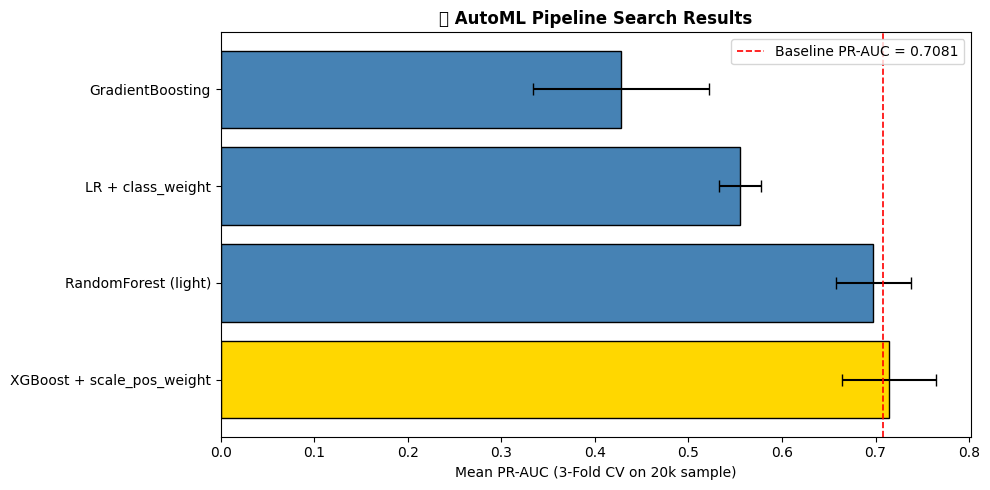

In [ ]:


from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, train_test_split as tts

print("🤖 Running AutoML Pipeline Search (fast version)...\n")

# -- Reuse the same 20k tuning sample for consistency --
_, X_tune, _, y_tune = tts(
    X_train_scaled, y_train,
    test_size    = 20_000 / len(y_train),
    stratify     = y_train,
    random_state = 42
)
print(f"✅ Using {len(y_tune):,} row sample for pipeline search")

# -- Define pipeline search space --
# Each entry is a (name, pipeline) pair
# We skip SMOTE here — class_weight handles imbalance faster
# We also include our already-tuned models as reference points
automl_space = [

    # Simple logistic regression baseline
    ("LR + class_weight",
     Pipeline([
         ('scaler', RobustScaler()),
         ('m', LogisticRegression(C=0.01, class_weight='balanced',
                                  max_iter=1000, random_state=42))
     ])),

    # Gradient Boosting — different boosting algorithm to XGBoost
    ("GradientBoosting",
     Pipeline([
         ('m', GradientBoostingClassifier(
             n_estimators=100, learning_rate=0.1,
             max_depth=4, subsample=0.8, random_state=42))
     ])),

    # Lightweight Random Forest for comparison
    ("RandomForest (light)",
     Pipeline([
         ('m', RandomForestClassifier(
             n_estimators=100, max_depth=10,
             class_weight='balanced', random_state=42, n_jobs=-1))
     ])),

    # XGBoost with scale_pos_weight — already proven strong
    ("XGBoost + scale_pos_weight",
     Pipeline([
         ('m', XGBClassifier(
             scale_pos_weight=imbalance_ratio,
             n_estimators=200, max_depth=4, learning_rate=0.1,
             eval_metric='aucpr', use_label_encoder=False,
             random_state=42, n_jobs=-1))
     ])),
]

# -- Evaluate each pipeline using 3-fold CV on the tuning sample --
automl_results = []

for name, pipeline in automl_space:
    scores = cross_val_score(
        pipeline, X_tune, y_tune,
        cv      = cv,                      # 3-fold StratifiedKFold from Section 8
        scoring = 'average_precision',     # PR-AUC — best metric for fraud
        n_jobs  = -1
    )
    automl_results.append({
        'Pipeline':    name,
        'Mean PR-AUC': round(scores.mean(), 4),
        'Std':         round(scores.std(),  4)
    })
    print(f"  ✔ {name:<35}  PR-AUC = {scores.mean():.4f}  ±{scores.std():.4f}")

# -- Rank pipelines best to worst --
automl_df = pd.DataFrame(automl_results).sort_values('Mean PR-AUC', ascending=False)
print("\n🏆 AutoML Pipeline Ranking:")
print("=" * 55)
print(automl_df.to_string(index=False))

# -- Fit best pipeline on full training data & evaluate on test set --
best_automl_name     = automl_df.iloc[0]['Pipeline']
best_automl_pipeline = dict(automl_space)[best_automl_name]

print(f"\n⏳ Training best pipeline '{best_automl_name}' on full data...")
best_automl_pipeline.fit(X_train_scaled, y_train)
print("✅ Done!")

tpot_pred    = best_automl_pipeline.predict(X_test_scaled)
tpot_prob    = best_automl_pipeline.predict_proba(X_test_scaled)[:, 1]
tpot_metrics = evaluate_model(
    f"AutoML Best ({best_automl_name})", y_test, tpot_pred, tpot_prob
)

# -- Visualise AutoML results --
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(automl_df))]
plt.barh(automl_df['Pipeline'], automl_df['Mean PR-AUC'],
         xerr=automl_df['Std'], color=colors, edgecolor='black', capsize=4)
plt.xlabel('Mean PR-AUC (3-Fold CV on 20k sample)')
plt.title('🤖 AutoML Pipeline Search Results', fontweight='bold')
plt.axvline(bl_metrics['Avg Precision'], color='red', linestyle='--',
            linewidth=1.2, label=f"Baseline PR-AUC = {bl_metrics['Avg Precision']:.4f}")
plt.legend()
plt.tight_layout()
plt.savefig('automl_results.png', dpi=150)
plt.show()


📊 FULL MODEL COMPARISON — FRAUD DETECTION
                                   Model  Precision   Recall     F1 ROC-AUC Avg Precision    F1 Δ ROC-AUC Δ Avg Precision Δ
          Baseline — Logistic Regression   0.058328 0.918367 0.1097  0.9702        0.7081 +0.0000   +0.0000         +0.0000
                     Tuned Random Forest   0.887640 0.806122 0.8449  0.9659        0.8662 +0.7352   -0.0043         +0.1581
                  Tuned XGBoost (Optuna)   0.830000 0.846939 0.8384  0.9695        0.8782 +0.7287   -0.0007         +0.1701
                         Voting Ensemble   0.831683 0.857143 0.8442  0.9713        0.8719 +0.7345   +0.0012         +0.1638
AutoML Best (XGBoost + scale_pos_weight)   0.583333 0.857143 0.6942  0.9820        0.8498 +0.5845   +0.0118         +0.1417


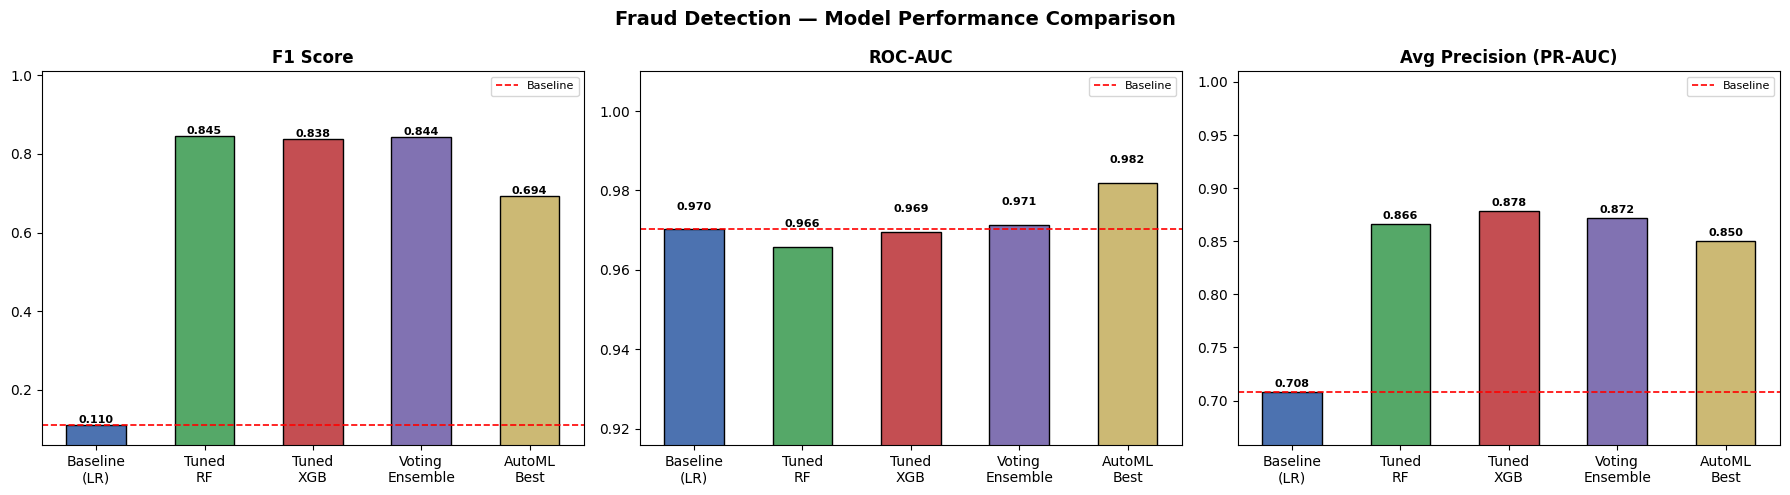

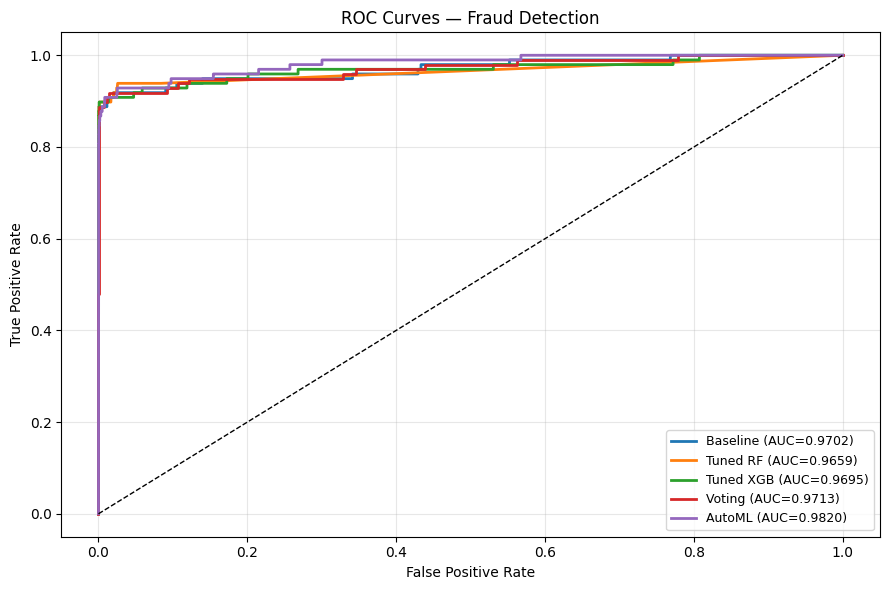

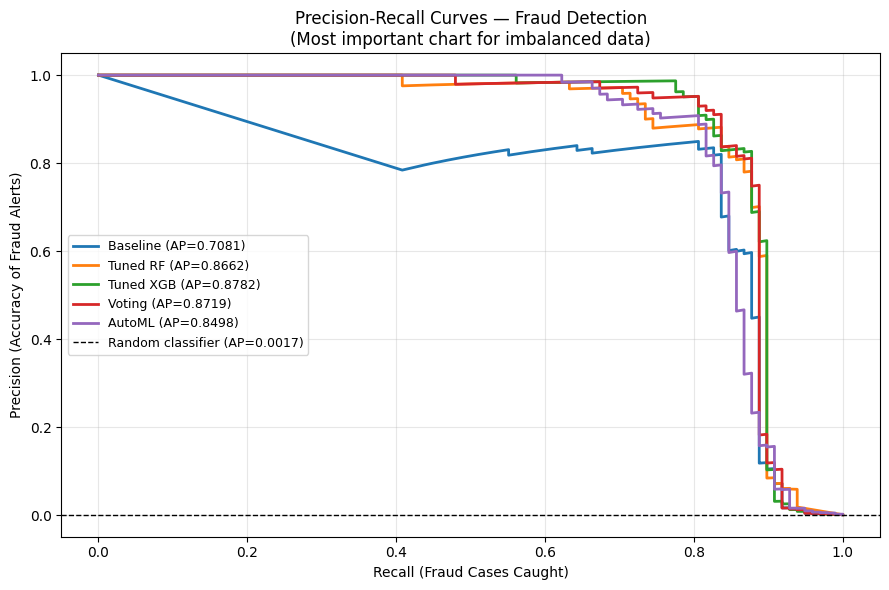

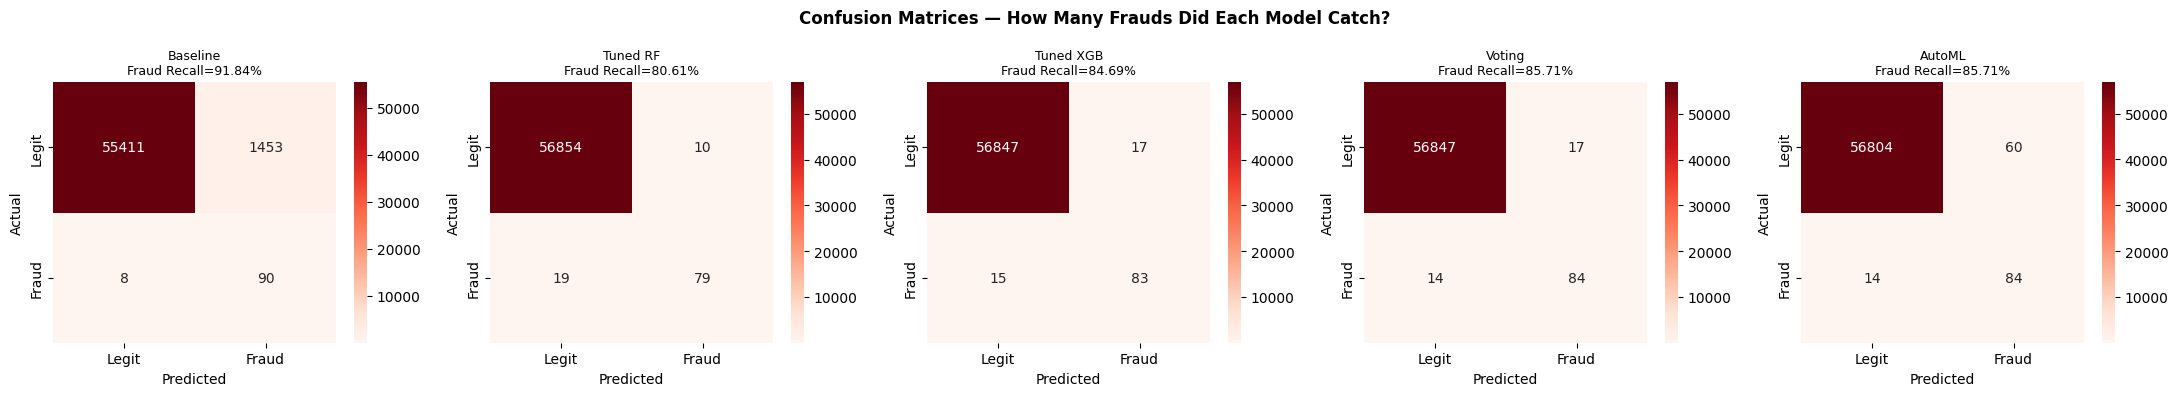

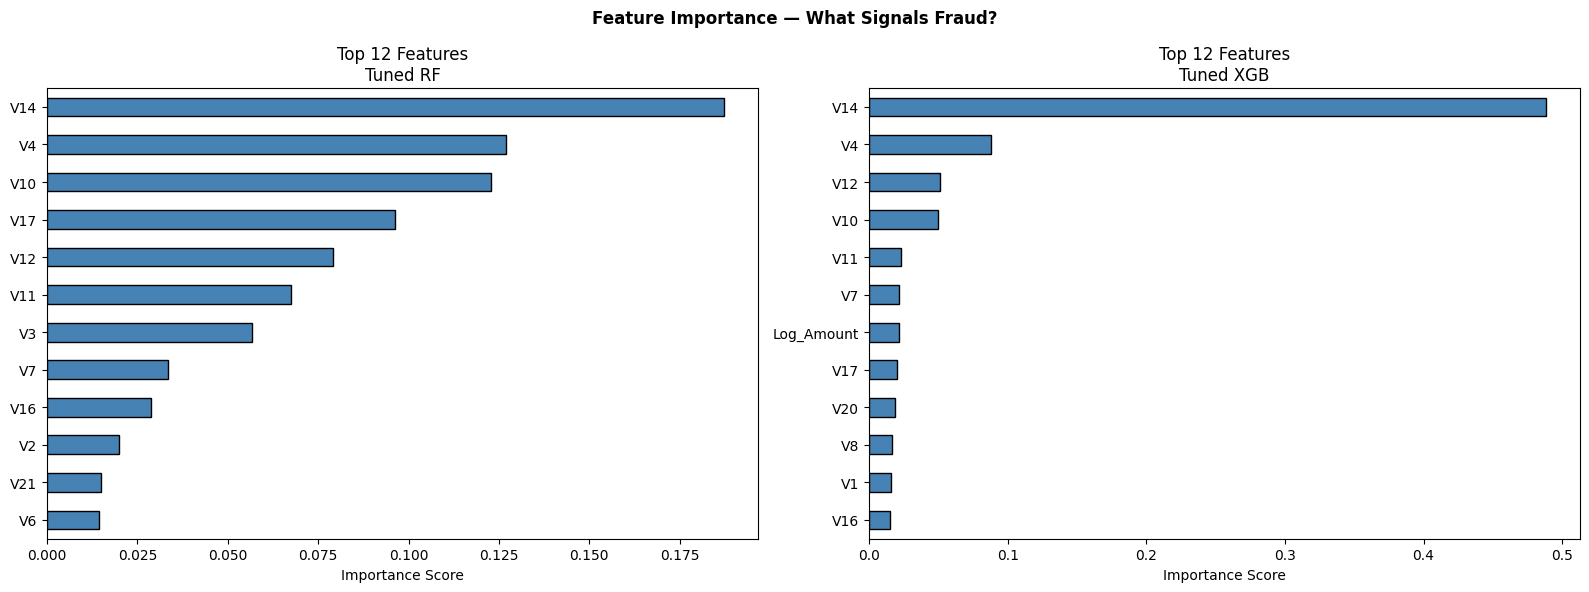

In [13]:
# ============================================================
# SECTION 11: FULL COMPARISON TABLE
# ============================================================

all_metrics = [bl_metrics, rf_metrics, xgb_metrics, vote_metrics, tpot_metrics]
comparison  = pd.DataFrame(all_metrics)

# Calculate improvement delta vs baseline for key metrics
for col in ['F1', 'ROC-AUC', 'Avg Precision']:
    baseline_val = comparison.loc[comparison['Model'].str.contains('Baseline'), col].values[0]
    comparison[f'{col} Δ'] = (comparison[col] - baseline_val).map('{:+.4f}'.format)
    comparison[col]        = comparison[col].map('{:.4f}'.format)

print("\n📊 FULL MODEL COMPARISON — FRAUD DETECTION")
print("=" * 90)
print(comparison.to_string(index=False))


# ============================================================
# SECTION 12: VISUALISATIONS
# 12a — F1, ROC-AUC, Avg Precision bar charts
# 12b — ROC curves
# 12c — Precision-Recall curves (most important for fraud)
# 12d — Confusion matrices
# 12e — Feature importance
# ============================================================

model_labels = ['Baseline\n(LR)', 'Tuned\nRF', 'Tuned\nXGB', 'Voting\nEnsemble', 'AutoML\nBest']
f1s   = [bl_metrics['F1'],    rf_metrics['F1'],    xgb_metrics['F1'],
         vote_metrics['F1'],  tpot_metrics['F1']]
aucs  = [bl_metrics['ROC-AUC'], rf_metrics['ROC-AUC'], xgb_metrics['ROC-AUC'],
         vote_metrics['ROC-AUC'], tpot_metrics['ROC-AUC']]
aps   = [bl_metrics['Avg Precision'], rf_metrics['Avg Precision'],
         xgb_metrics['Avg Precision'], vote_metrics['Avg Precision'],
         tpot_metrics['Avg Precision']]
palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

# -- 12a: Bar Charts --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fraud Detection — Model Performance Comparison', fontsize=14, fontweight='bold')

for ax, vals, title, baseline_val in zip(
    axes,
    [f1s, aucs, aps],
    ['F1 Score', 'ROC-AUC', 'Avg Precision (PR-AUC)'],
    [bl_metrics['F1'], bl_metrics['ROC-AUC'], bl_metrics['Avg Precision']]
):
    bars = ax.bar(model_labels, vals, color=palette, edgecolor='black', width=0.55)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(min(vals) - 0.05, 1.01)
    ax.axhline(baseline_val, color='red', linestyle='--', linewidth=1.2, label='Baseline')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fraud_comparison.png', dpi=150)
plt.show()

# -- 12b: ROC Curves --
plt.figure(figsize=(9, 6))
for name, prob in [('Baseline', bl_prob), ('Tuned RF', rf_prob),
                    ('Tuned XGB', xgb_prob), ('Voting', vote_prob), ('AutoML', tpot_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test,prob):.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Fraud Detection')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_fraud.png', dpi=150)
plt.show()

# -- 12c: Precision-Recall Curves --
# PR curves are more informative than ROC for heavily imbalanced data
# A random classifier would score PR-AUC ≈ 0.0017 (fraud rate)
# so any score well above that is meaningful
plt.figure(figsize=(9, 6))
for name, prob in [('Baseline', bl_prob), ('Tuned RF', rf_prob),
                    ('Tuned XGB', xgb_prob), ('Voting', vote_prob), ('AutoML', tpot_prob)]:
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec_vals, prec_vals, lw=2, label=f'{name} (AP={ap:.4f})')
plt.axhline(y_test.mean(), color='k', linestyle='--', lw=1,
            label=f'Random classifier (AP={y_test.mean():.4f})')
plt.xlabel('Recall (Fraud Cases Caught)')
plt.ylabel('Precision (Accuracy of Fraud Alerts)')
plt.title('Precision-Recall Curves — Fraud Detection\n(Most important chart for imbalanced data)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_fraud.png', dpi=150)
plt.show()

# -- 12d: Confusion Matrices --
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pred) in zip(axes, [
    ('Baseline', bl_pred), ('Tuned RF', rf_pred), ('Tuned XGB', xgb_pred),
    ('Voting', vote_pred), ('AutoML', tpot_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    # Show fraud recall directly on chart — most critical number
    fraud_recall = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0
    ax.set_title(f'{name}\nFraud Recall={fraud_recall:.2%}', fontsize=9)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — How Many Frauds Did Each Model Catch?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_fraud.png', dpi=150)
plt.show()

# -- 12e: Feature Importance --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (model, name) in zip(axes, [(best_rf, 'Tuned RF'), (best_xgb, 'Tuned XGB')]):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp.nlargest(12).sort_values().plot(kind='barh', ax=ax,
                                        color='steelblue', edgecolor='black')
    ax.set_title(f'Top 12 Features\n{name}')
    ax.set_xlabel('Importance Score')
plt.suptitle('Feature Importance — What Signals Fraud?', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_fraud.png', dpi=150)
plt.show()